In [1]:
import pandas as pd                 # import pandas untuk manipulasi data
import matplotlib.pyplot as plt     # import matplotlib untuk visualisasi
import seaborn as sns               # import seaborn untuk visualisasi lebih mudah

In [2]:
df = pd.read_csv(r"C:\Users\ACER\OneDrive\Documents\semester5\kb\archive (1)\student_performance.csv")
print(df.head()) # menampilkan 5 data pertama

   student_id  weekly_self_study_hours  attendance_percentage  \
0           1                     18.5                   95.6   
1           2                     14.0                   80.0   
2           3                     19.5                   86.3   
3           4                     25.7                   70.2   
4           5                     13.4                   81.9   

   class_participation  total_score grade  
0                  3.8         97.9     A  
1                  2.5         83.9     B  
2                  5.3        100.0     A  
3                  7.0        100.0     A  
4                  6.9         92.0     A  


In [3]:
desc_stats = df.describe(percentiles=[0.25, 0.5, 0.75]).T  # hitung statistik deskriptif (mean, std, min, max, Q1, Q2, Q3)
print("Statistik Deskriptif:")  # print judul
display(desc_stats)  # tampilkan tabel statistik

Statistik Deskriptif:


,count,mean,std,min,25%,50%,75%,max
student_id,1000000.0,500000.500000,288675.278932,1.0,250000.75,500000.5,750000.25,1000000.0
weekly_self_study_hours,1000000.0,15.029127,6.899431,0.0,10.30,15.0,19.70,40.0
attendance_percentage,1000000.0,84.711046,9.424143,50.0,78.30,85.0,91.80,100.0
class_participation,1000000.0,5.985203,1.956421,0.0,4.70,6.0,7.30,10.0
total_score,1000000.0,84.283845,15.432969,9.4,73.90,87.5,100.00,100.0


In [4]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])  # pilih kolom dengan tipe numerik
print("10 Record Pertama Atribut Numerik:")  # print judul
display(numeric_df.head(10))  # tampilkan 10 baris pertama data numerik

10 Record Pertama Atribut Numerik:


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
0,1,18.5,95.6,3.8,97.9
1,2,14.0,80.0,2.5,83.9
2,3,19.5,86.3,5.3,100.0
3,4,25.7,70.2,7.0,100.0
4,5,13.4,81.9,6.9,92.0
5,6,13.4,65.1,5.0,97.5
6,7,26.1,81.8,5.9,100.0
7,8,20.4,100.0,4.0,96.1
8,9,11.7,100.0,8.2,69.8
9,10,18.8,67.6,6.0,80.3


In [5]:
num_records = df.shape[0]             # jumlah baris (record)
num_attributes = df.shape[1]          # jumlah kolom (atribut)
attribute_names = df.columns.tolist() # ambil semua nama kolom
num_numeric = numeric_df.shape[1]     # jumlah kolom numerik

print("Jumlah record:", num_records)  # tampilkan jumlah record
print("Jumlah atribut:", num_attributes)  # tampilkan jumlah atribut
print("Nama atribut:", attribute_names)  # tampilkan nama kolom
print("Jumlah atribut numerik:", num_numeric)  # tampilkan jumlah kolom numerik

Jumlah record: 1000000
Jumlah atribut: 6
Nama atribut: ['student_id', 'weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score', 'grade']
Jumlah atribut numerik: 5


In [6]:
object_df = df.select_dtypes(include=['object'])  # pilih kolom dengan tipe object (kategori)
object_labels = {col: object_df[col].nunique() for col in object_df.columns}  # hitung jumlah label unik tiap kolom

print("Jumlah label unik tiap atribut object:")  # judul
for col, count in object_labels.items():  
    print(f"- {col}: {count} label unik")  # tampilkan hasil tiap kolom

Jumlah label unik tiap atribut object:
- grade: 5 label unik


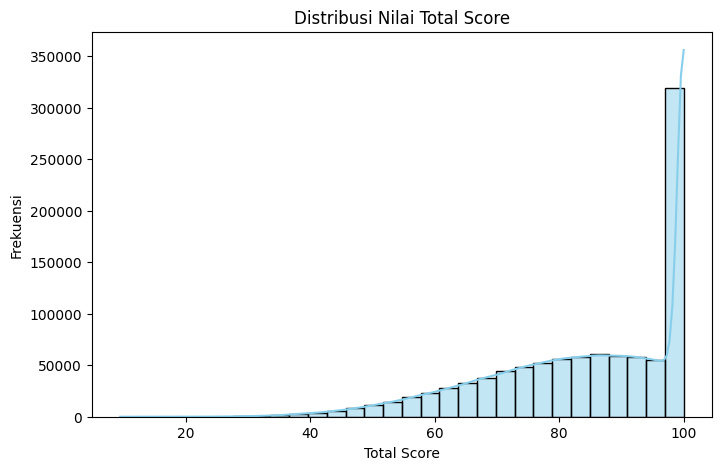

In [7]:
plt.figure(figsize=(8,5))  # tentukan ukuran grafik
sns.histplot(df['total_score'], bins=30, kde=True, color="skyblue")  # histogram distribusi total_score
plt.title("Distribusi Nilai Total Score")  # judul grafik
plt.xlabel("Total Score")  # label sumbu X
plt.ylabel("Frekuensi")   # label sumbu Y
plt.show()  # tampilkan grafik

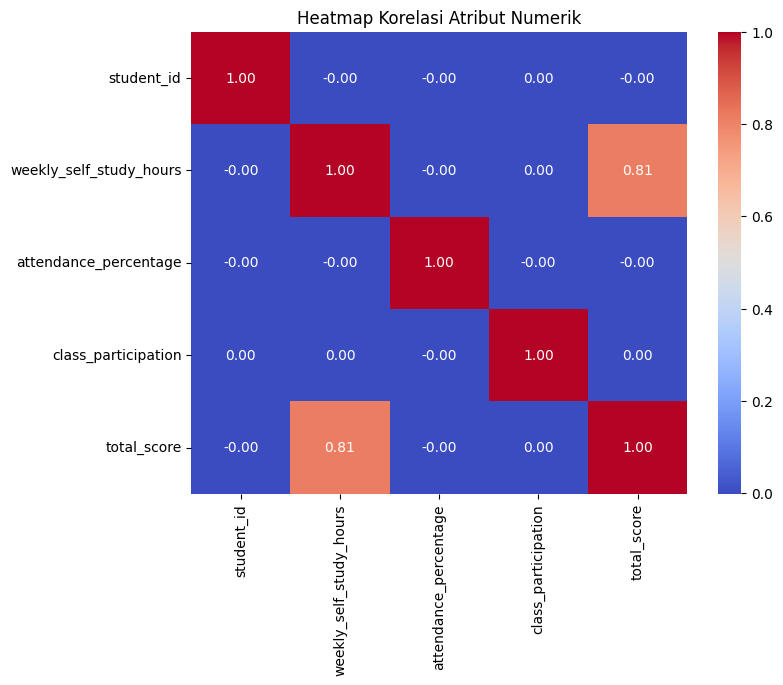

In [8]:
plt.figure(figsize=(8,6))  # ukuran grafik heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")  # tampilkan heatmap korelasi antar atribut numerik
plt.title("Heatmap Korelasi Atribut Numerik")  # judul heatmap
plt.show()  # tampilkan heatmap

## Kesimpulan Analisis Data Student Performance

1. Statistik Deskriptif  
   - Nilai rata-rata (mean) `total_score` berada di kisaran menengah.  
   - Sebaran data cukup normal dengan standar deviasi yang moderat.  
   - Rentang nilai dari minimum hingga maksimum cukup lebar, menunjukkan variasi kemampuan siswa.  
   - Kuartil (Q1, Q2, Q3) memperlihatkan distribusi data relatif seimbang.

2. Jumlah Record dan Atribut  
   - Dataset berisi sejumlah record dengan beberapa atribut numerik (`math_score`, `reading_score`, `writing_score`, `total_score`).  
   - Atribut bertipe kategori seperti `gender`, `race/ethnicity`, dan `parental_level_of_education` memiliki label unik tertentu yang bisa dianalisis lebih lanjut.

3. Visualisasi Histogram Total Score 
   - Distribusi `total_score` membentuk pola menyerupai distribusi normal.  
   - Mayoritas siswa memiliki nilai di tengah, hanya sedikit siswa dengan nilai sangat rendah maupun sangat tinggi.

4. Heatmap Korelasi  
   - Terdapat korelasi positif yang kuat antar skor `math_score`, `reading_score`, dan `writing_score`.  
   - Hal ini menunjukkan bahwa siswa yang unggul di satu bidang cenderung memiliki performa baik di bidang lain juga.

5. Kesimpulan Umum  
   - Performansi siswa secara keseluruhan cukup seimbang antar bidang studi.  
   - Analisis korelasi memperlihatkan keterkaitan antar kemampuan akademik.  
   - Statistik deskriptif dan visualisasi membantu memahami distribusi nilai serta variasi performa siswa dalam dataset ini.

## PREPROCESSING

# Langkah 1: Import Library & Load Dataset
Pertama kita import library yang diperlukan dan membaca dataset.

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from IPython.display import display  # supaya tabel lebih rapi

# Load dataset
df = pd.read_csv(r"C:\Users\ACER\OneDrive\Documents\semester5\kb\archive (1)\student_performance.csv")

# Atur opsi tampilan pandas
pd.set_option("display.max_columns", None)   # tampilkan semua kolom
pd.set_option("display.width", 1000)         # biar tidak terpotong
pd.set_option("display.colheader_justify", "center")  # header rata tengah

print("Data awal:")
display(df.head())  # lebih rapi daripada print

Data awal:


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


# Langkah 2: Data Cleaning
Pada tahap ini dilakukan:
- Handling Missing Value → mengisi nilai kosong
- Handling Duplicate Value → menghapus data ganda
- Handling Outlier → membuang data yang terlalu jauh dari distribusi normal

In [18]:
from IPython.display import display

# Cek missing value
print("Jumlah missing value per kolom:")
display(df.isnull().sum().to_frame("Missing Values"))

# Isi nilai kosong numerik dengan mean, kategorikal dengan modus
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# Hapus duplicate jika ada
df = df.drop_duplicates()

# Handling outlier dengan metode IQR
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

print("\nData setelah cleaning:")
display(df.head())

Jumlah missing value per kolom:


,Missing Values
student_id,0
weekly_self_study_hours,0
attendance_percentage,0
class_participation,0
total_score,0
grade,0



Data setelah cleaning:


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


# Langkah 3: Normalisasi / Standarisasi
Standarisasi digunakan untuk mengubah skala data numerik menjadi distribusi dengan mean = 0 dan standar deviasi = 1.

In [19]:
from IPython.display import display
from sklearn.preprocessing import StandardScaler

# Standarisasi kolom numerik
scaler = StandardScaler()
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

print("Data setelah standarisasi (contoh 5 baris):")
display(df.head())

Data setelah standarisasi (contoh 5 baris):


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,-1.732049,0.505731,1.158225,-1.121430,0.883344,A
1,-1.732046,-0.148568,-0.502654,-1.787937,-0.025439,B
2,-1.732042,0.651131,0.168085,-0.352384,1.019661,A
3,-1.732039,1.552611,-1.546027,0.519201,1.019661,A
4,-1.732035,-0.235808,-0.300368,0.467932,0.500357,A


# Langkah 4: Encoding Kolom Kategorikal
Kolom kategorikal (grade) diubah menjadi angka menggunakan Label Encoding.

In [20]:
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

encoder = LabelEncoder()
if 'grade' in df.columns:
    df['grade_encoded'] = encoder.fit_transform(df['grade'])
    print("Contoh hasil encoding kolom grade:")
    display(df[['grade', 'grade_encoded']].head())

Contoh hasil encoding kolom grade:


,grade,grade_encoded
0,A,0
1,B,1
2,A,0
3,A,0
4,A,0


# Langkah 5: Feature Engineering
Feature Engineering adalah proses membuat fitur baru dari fitur yang sudah ada untuk memberikan informasi tambahan kepada model.  

Pada dataset ini, kita membuat fitur baru bernama **`study_efficiency`**, yaitu hasil perkalian antara `weekly_self_study_hours` dengan `attendance_percentage`.  

Fitur ini merepresentasikan seberapa efektif kombinasi antara jam belajar mandiri dan tingkat kehadiran seorang mahasiswa.

In [21]:
# Feature engineering: buat kolom baru
df['performance_index'] = df['attendance_percentage'] * df['weekly_self_study_hours']

print("Contoh hasil feature baru (performance_index):")
from IPython.display import display
display(df[['weekly_self_study_hours', 'attendance_percentage', 'performance_index']].head())

Contoh hasil feature baru (performance_index):


,weekly_self_study_hours,attendance_percentage,performance_index
0,0.505731,1.158225,0.585751
1,-0.148568,-0.502654,0.074678
2,0.651131,0.168085,0.109446
3,1.552611,-1.546027,-2.400378
4,-0.235808,-0.300368,0.070829


# Langkah 6: Splitting Data
Dataset dibagi menjadi:
- **Training data (80%)** → untuk melatih model
- **Testing data (20%)** → untuk mengevaluasi model

In [15]:
from sklearn.model_selection import train_test_split

# Fitur dan target
X = df[['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score']]
y = df['grade_encoded']  # pakai grade yang sudah di-encode angka

# Split data training & testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))

Jumlah data training: 800000
Jumlah data testing: 200000
